# Benchmark 1: throughput vs concurrency
Steady-state write throughput at concurrency 1/10/50/100, single-node baseline vs cluster. Run `bench/01-throughput-sweep.sh` first.

In [1]:
import sys
sys.path.insert(0, ".")
import matplotlib.pyplot as plt
from plot_style import load, agg


In [2]:
df = load("throughput-sweep.csv")
df

,clusterSize,concurrency,run,reqPerSec,p50Ms,p95Ms,p99Ms
0,1,1,1,178.78,5.56,5.68,5.83
1,1,10,1,1128.47,6.59,6.95,7.22
2,1,25,1,2573.31,9.18,9.55,9.97
3,1,50,1,4865.48,9.30,9.97,10.47
4,1,75,1,6164.17,11.32,12.94,17.17
5,1,100,1,6022.50,13.57,26.94,27.71
6,3,1,1,2143.80,0.43,0.61,0.89
7,3,10,1,4268.63,1.86,2.46,2.75
8,3,25,1,3619.81,6.33,9.53,10.31
9,3,50,1,3740.52,12.68,15.81,18.67


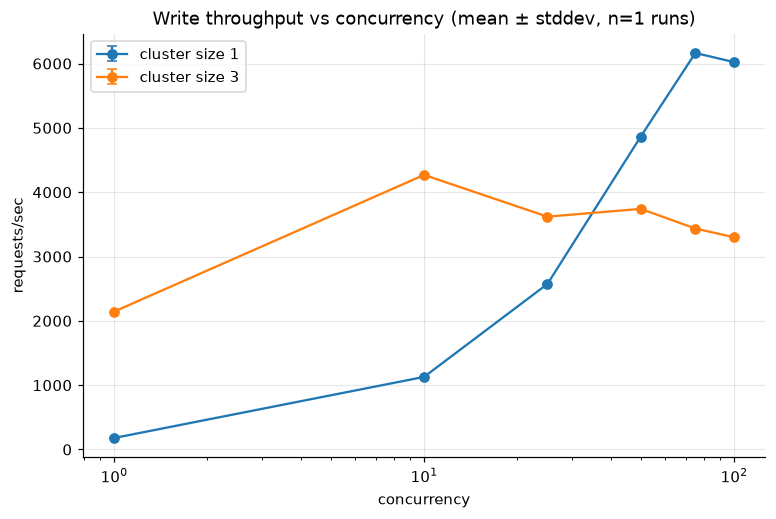

In [3]:
summary = agg(df, ["clusterSize", "concurrency"], "reqPerSec")

fig, ax = plt.subplots()
for size, group in summary.groupby("clusterSize"):
    group = group.sort_values("concurrency")
    ax.errorbar(group["concurrency"], group["mean"], yerr=group["std"],
                marker="o", capsize=3, label=f"cluster size {size}")
ax.set_xscale("log")
ax.set_xlabel("concurrency")
ax.set_ylabel("requests/sec")
ax.set_title(f"Write throughput vs concurrency (mean ± stddev, n={df['run'].nunique()} runs)")
ax.legend()
plt.show()

### Plateau detection
The plateau (where added concurrency stops buying throughput) matters more than the peak - it's the point where replication/IO, not client load, is the bottleneck.

In [4]:
for size, group in summary.groupby("clusterSize"):
    group = group.sort_values("concurrency").reset_index(drop=True)
    pct_change = group["mean"].pct_change() * 100
    plateau_row = group.iloc[1:][pct_change.iloc[1:].abs() < 5]
    plateau_c = plateau_row["concurrency"].iloc[0] if len(plateau_row) else None
    print(f"cluster size {size}: plateaus around concurrency={plateau_c}")

cluster size 1: plateaus around concurrency=100
cluster size 3: plateaus around concurrency=50
